# 1. Setup
## 1.1 Config + Logger import

In [89]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [90]:
# ====== Imports ======
# Config
from config_loader import CONFIG

# Logger: LoggerManager + global configuration
from loggerplusplus import LoggerManager, LogLevels, LoggerConfig, Logger, logger_colors

LoggerManager.enable_files_logs_monitoring_only_for_one_logger = (
    CONFIG.LOGGER_MANAGER_ENABLE_FILES_LOGS_MONITORING_ONLY_FOR_ONE_LOGGER
)
LoggerManager.enable_dynamic_config_update = CONFIG.LOGGER_MANAGER_ENABLE_DYNAMIC_CONFIG_UPDATE
LoggerManager.enable_unique_logger_identifier = CONFIG.LOGGER_MANAGER_ENABLE_UNIQUE_LOGGER_IDENTIFIER

LoggerManager.global_config = LoggerConfig.from_kwargs(
    colors=getattr(logger_colors, CONFIG.LOGGER_COLORS),
    path=CONFIG.LOGGER_PATH,
    # LogLevels
    decorator_log_level=getattr(LogLevels, CONFIG.LOGGER_DECORATOR_LOG_LEVEL),
    print_log_level=getattr(LogLevels, CONFIG.LOGGER_PRINT_LOG_LEVEL),
    file_log_level=getattr(LogLevels, CONFIG.LOGGER_FILE_LOG_LEVEL),
    # Loggers Output
    print_log=CONFIG.LOGGER_PRINT_LOG,
    write_to_file=CONFIG.LOGGER_WRITE_TO_FILE,
    # Monitoring
    display_monitoring=CONFIG.LOGGER_DISPLAY_MONITORING,
    files_monitoring=CONFIG.LOGGER_FILES_MONITORING,
    file_size_unit=CONFIG.LOGGER_FILE_SIZE_UNIT,
    disk_alert_threshold_percent=CONFIG.LOGGER_DISK_ALERT_THRESHOLD_PERCENT,
    log_files_size_alert_threshold_percent=CONFIG.LOGGER_FILES_SIZE_ALERT_THRESHOLD_PERCENT,
    max_log_file_size=CONFIG.LOGGER_MAX_LOG_FILE_SIZE,
    # Placement
    identifier_max_width=CONFIG.LOGGER_IDENTIFIER_MAX_WIDTH,
    filename_lineno_max_width=CONFIG.LOGGER_FILENAME_LINENO_MAX_WIDTH,
)

## 1.2 Importing Libraries

In [91]:
import matplotlib.pyplot as plt
import numpy as np
import math
import time

from geometry import OrientedPoint, Point

# 2 Path Planner tests
## 2.1 Delta Planner

In [92]:
from navigation.path_planner import DeltaPathPlanner, DeltaPathPlannerParams, DeltaPathPlannerPlanPathParams

### Case 1: Displacement only

In [93]:
dummy_path_planner_params = DeltaPathPlannerParams(distance=10.0, rotation=0.0)
dummy_path_planner = DeltaPathPlanner(dummy_path_planner_params)

start = OrientedPoint(0, 0, 0)
path1 = dummy_path_planner.plan_path(DeltaPathPlannerPlanPathParams(start=start))
print("Displacement only:", path1[-1])

Displacement only: POINT (10 0), theta: 0


### Case 2: Rotation only

In [94]:
dummy_path_planner_params = DeltaPathPlannerParams(distance=0.0, rotation=math.pi / 2)
dummy_path_planner = DeltaPathPlanner(dummy_path_planner_params)

start = OrientedPoint(0, 0, 0)
path2 = dummy_path_planner.plan_path(DeltaPathPlannerPlanPathParams(start=start))
print("Rotation only:", path2[-1])

Rotation only: POINT (0 0), theta: 1.5707963267948966


### Case 3: Displacement + Rotation

In [95]:
dummy_path_planner_params = DeltaPathPlannerParams(distance=10.0, rotation=math.pi / 4)
dummy_path_planner = DeltaPathPlanner(dummy_path_planner_params)

start = OrientedPoint(0, 0, 0)
path3 = dummy_path_planner.plan_path(DeltaPathPlannerPlanPathParams(start=start))
print("Displacement + Rotation:", path3[-1])

Displacement + Rotation: POINT (10 0), theta: 0.7853981633974483


## 2.2 Basic Planner

In [96]:
from navigation.path_planner import BasicPathPlanner, BasicPathPlannerParams, Direction, BasicPathPlannerPlanPathParams

### Case 1: Forward 

In [97]:
basic_path_planner_params = BasicPathPlannerParams()
basic_path_planner = BasicPathPlanner(basic_path_planner_params)

start = OrientedPoint(0, 0, 0)
basic_path_planner.plan_path(BasicPathPlannerPlanPathParams(start=start, goal=OrientedPoint(10, 0, 0)))

[POINT (0 0), theta: 0, POINT (10 0), theta: 0]

### Case 2: Backward 

In [98]:
basic_path_planner_params = BasicPathPlannerParams(direction=Direction.BACKWARD)
basic_path_planner = BasicPathPlanner(basic_path_planner_params)

start = OrientedPoint(0, 0, 0)
basic_path_planner.plan_path(BasicPathPlannerPlanPathParams(start=start, goal=OrientedPoint(10, 0, 0)))

[POINT (0 0), theta: 3.141592653589793, POINT (10 0), theta: 3.141592653589793]

## 2.3 A* Planner

### Init Grid and Grid Manager

In [99]:
from arena import GridManager
logger_grid_manager = Logger(
        identifier="GridManager",
        follow_logger_manager_rules=True,
    )

grid_chunk_size = 10

grid_manager = GridManager(logger=logger_grid_manager, chunk_size=grid_chunk_size, width=100, height=100)
grid_test = grid_manager.static_and_dynamic_grid
grid_test.__str__()

'<Grid width=10 height=10>'

### A* Planner Init

In [100]:
from navigation.path_planner import AStarPathPlanner, AStarPathPlannerParams, AStarPathPlannerPlanPathParams

FORWARD

In [101]:
logger_astar = Logger(
        identifier="A*",
        follow_logger_manager_rules=False,
        LogLevels=LogLevels.DEBUG,
    )

start = OrientedPoint(0, 0, 0)
goal = OrientedPoint(99, 10, 0)

astar_path_planner_params = AStarPathPlannerParams(start=start, goal=goal, grid=grid_test, chunk_size=grid_chunk_size, path_resolution=0.05)
astar_path_planner = AStarPathPlanner(params=astar_path_planner_params, logger=logger_astar)

path = astar_path_planner.plan_path(AStarPathPlannerPlanPathParams(start=start, goal=goal))

logger_astar.info("Path:" + str(path))


05:05:39.627112 -> [ A* ] [decorators.py:41]   DEBUG    | [base_path_planner] AStarPathPlanner.plan_path(self=AStarPathPla..., params=<navigation....) executed in 0.000422s
05:05:39.628010 -> [ A* ] [ 539690393.py:15]    INFO    | Path:[POINT (0 0), theta: 0, POINT (25 5), theta: 0.0, POINT (35 5), theta: 0.0, POINT (45 5), theta: 0.0, POINT (55 5), theta: 0.0, POINT (65 5), theta: 0.0, POINT (75 5), theta: 0.0, POINT (99 10), theta: 0]


BACKWARDS


In [102]:
astar_path_planner_params = AStarPathPlannerParams(start=start, goal=goal, 
                                                   grid=grid_test, 
                                                   chunk_size=grid_chunk_size, 
                                                   path_resolution=0.05,
                                                   direction=Direction.BACKWARD)
astar_path_planner = AStarPathPlanner(astar_path_planner_params)

start = OrientedPoint(0, 0, 0)
goal = OrientedPoint(99, 0, 0)

path = astar_path_planner.plan_path(AStarPathPlannerPlanPathParams(start=start, goal=goal))
logger_astar.info("Path:" + str(path))

05:05:39.678498 -> [ A* ] [4266683973.py:12]    INFO    | Path:[POINT (0 0), theta: 3.141592653589793, POINT (25 5), theta: 3.141592653589793, POINT (35 5), theta: 3.141592653589793, POINT (45 5), theta: 3.141592653589793, POINT (55 5), theta: 3.141592653589793, POINT (65 5), theta: 3.141592653589793, POINT (75 5), theta: 3.141592653589793, POINT (99 10), theta: 3.141592653589793]


# 3. SpeedProfile tests

In [103]:
from navigation.debug_functions import test_speed_profile

## 3.1 Basic SpeedProfile

Testing profile: <navigation.trajectory_planner.speed_profile.basic_speed_profile.BasicSpeedProfile object at 0x000001ED22D08FC0>


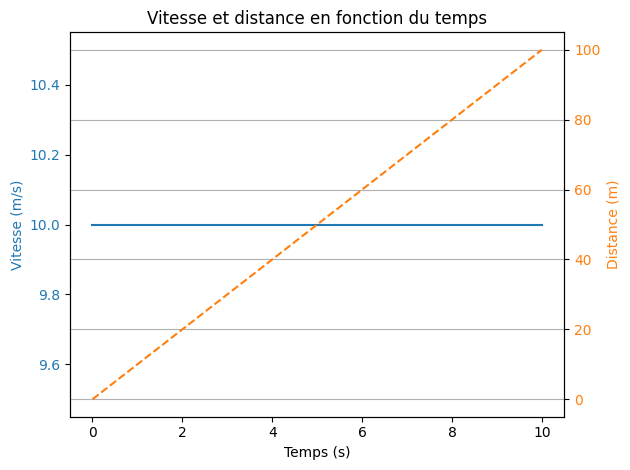

In [104]:
from navigation import BasicSpeedProfile

basic_speed_profile = BasicSpeedProfile(10)
test_speed_profile(basic_speed_profile, 100)

## 3.2 Linear Ramped SpeedProfile

Testing profile: <navigation.trajectory_planner.speed_profile.linear_ramped_speed_profile.LinearRampedSpeedProfile object at 0x000001ED26BD0A10>


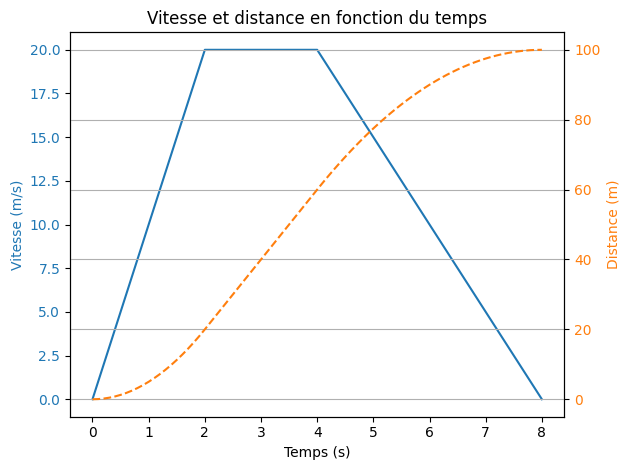

In [105]:
from navigation import LinearRampedSpeedProfile

linear_ramped_speed_profile = LinearRampedSpeedProfile(
    acceleration=10.0, max_speed=20.0, deceleration=5.0
)
test_speed_profile(linear_ramped_speed_profile, 100)

Testing profile: <navigation.trajectory_planner.speed_profile.linear_ramped_speed_profile.LinearRampedSpeedProfile object at 0x000001ED269615B0>


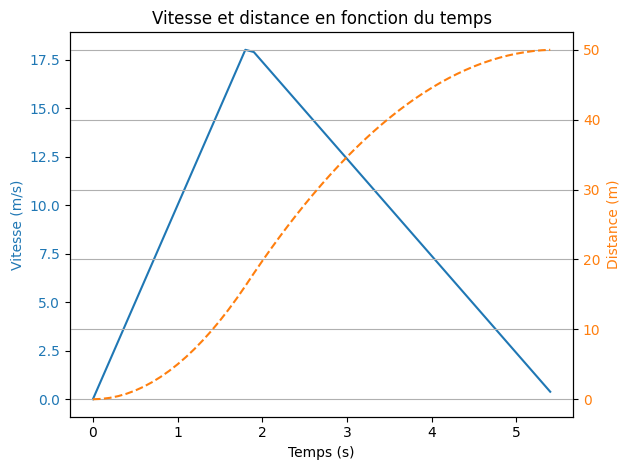

In [106]:
from navigation import LinearRampedSpeedProfile

linear_ramped_speed_profile = LinearRampedSpeedProfile(
    acceleration=10.0, max_speed=20.0, deceleration=5.0
)
test_speed_profile(linear_ramped_speed_profile, 50) # Not enough distance to accelerate to max speed

Testing profile: <navigation.trajectory_planner.speed_profile.linear_ramped_speed_profile.LinearRampedSpeedProfile object at 0x000001ED268C1BB0>


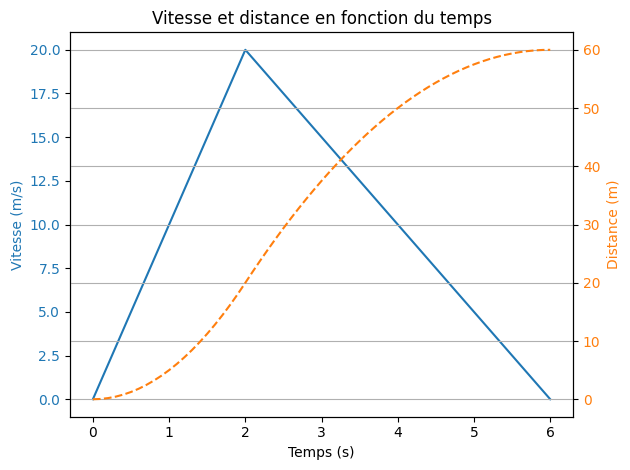

In [107]:
from navigation import LinearRampedSpeedProfile

linear_ramped_speed_profile = LinearRampedSpeedProfile(
    acceleration=10.0, max_speed=20.0, deceleration=5.0
)
test_speed_profile(linear_ramped_speed_profile, None)

# 4. Trajectory Planner tests

In [108]:
from navigation.debug_functions import test_trajectory_planning

In [109]:
# Create a path
path = [
    OrientedPoint(0, 0, 0),
    OrientedPoint(2, 1, math.pi/4),
    OrientedPoint(4, 0, math.pi/2),
    OrientedPoint(6, 3, math.pi)
]

## 4.0 Base Trajectory Planner

In [110]:
# from navigation import BaseTrajectoryPlanner, BaseTrajectoryPlannerParams

# base_trajectory_planner_params = BaseTrajectoryPlannerParams(10.0)
# base_trajectory_planner = BaseTrajectoryPlanner(base_trajectory_planner_params)

# for i in range(5):
#     print("START")
#     base_trajectory_planner.start_planning()

#     for i in range(5):
#         base_trajectory_planner.get_plan()
#         time.sleep(0.1)
        
#     print("STOP")
#     base_trajectory_planner.stop_planning()
#     time.sleep(1.0)

## 4.1 Sequential Trajectory Planner

In [111]:
from navigation import (
    # Import TrajectoryPlanner
    SequentialTrajectoryPlanner, SequentialTrajectoryPlannerParams, 
    # Import SpeedProfile
    LinearRampedSpeedProfile, SpeedProfiler, BasicSpeedProfile
)

sequential_trajectory_planner = SequentialTrajectoryPlanner(
    SequentialTrajectoryPlannerParams(
        respect_intermediate_orientation=True
    ),
    SpeedProfiler(
        linear_speed_profile=LinearRampedSpeedProfile(
            acceleration=10.0, max_speed=20.0, deceleration=5.0
        ),
        angular_speed_profile=LinearRampedSpeedProfile(
            acceleration=1.0, max_speed=2.0, deceleration=0.5
        )
    )
)

# sequential_trajectory_planner = SequentialTrajectoryPlanner(
#     SequentialTrajectoryPlannerParams(),
#     SpeedProfiler(
#         linear_speed_profile=BasicSpeedProfile(
#             speed=20.0
#         ),
#         angular_speed_profile=BasicSpeedProfile(
#             speed=2.0, deceleration=0.5
#         )
#     )
# )

In [112]:
#test_trajectory_planning(sequential_trajectory_planner, path)

## 4.2 Basic Trajectory Planner

# 5 NavigatorTask

In [113]:
from navigation import NavigatorTaskParams

## 5.1 Basic NavigatorTask
- BasicPathPlanner
- SequentialTrajectoryPlanner
- LinearRampedSpeedProfile
- StopAndWaitAvoidance

In [114]:
from navigation import BasicPathPlannerParams, SequentialTrajectoryPlannerParams, LinearRampedSpeedProfile, SpeedProfiler, StopAndWaitAvoidanceParams

basic_navigator_task_params = NavigatorTaskParams(
    goal=OrientedPoint(100, 75, 0),
    timeout=None,
    path_planner_params=BasicPathPlannerParams(),
    trajectory_planner_params=SequentialTrajectoryPlannerParams(),
    speed_profiler=SpeedProfiler(
        linear_speed_profile=LinearRampedSpeedProfile(
            acceleration=10.0, max_speed=20.0, deceleration=5.0
        ),
        angular_speed_profile=LinearRampedSpeedProfile(
            acceleration=1.0, max_speed=2.0, deceleration=0.5
        )
    ),
    avoidance_params=StopAndWaitAvoidanceParams(
        acs_distance=10,
        timeout=10
    )
)

#  6 Navigator

In [ ]:
from arena import ShowArena, TeamColor

arena = ShowArena(
    logger=Logger(identifier="ShowArena", follow_logger_manager_rules=True),
    border_buffer=CONFIG.ARENA_BORDER_BUFFER,
    obstacle_buffer=CONFIG.ARENA_OBSTACLE_BUFFER,
    chunk_size=CONFIG.ARENA_CHUNK_SIZE,
    forbidden_cover_threshold=CONFIG.ARENA_FORBIDDEN_COVER_THRESHOLD,
    grid_manager_logger=Logger(identifier="GridManager", follow_logger_manager_rules=True)
)

arena.set_team_color(TeamColor.YELLOW)

start_ally_position = OrientedPoint(30, 30, 0)
start_enemy_position = Point(250, 100)

# Start position
arena.update(
    ally_position=start_ally_position,
    lidar_scan_polars=np.array([]),
    optimized_update=False,
    _enemy_position=start_enemy_position,
)
arena.visualize()

In [ ]:
from navigation import Navigator, NavigatorState, TrajectoryPlanCommand
navigator = Navigator()

In [ ]:
navigator.add_navigation_task(basic_navigator_task_params)

04:45:33.783395 -> [   Navigator   ] [ navigator.py:45]    INFO    | Added task to queue: <navigation.navigator.task.navigator_task_params.NavigatorTaskParams object at 0x000001ED254C3390>
04:45:33.784977 -> [   Navigator   ] [ navigator.py:32]    INFO    | Switched to new task: <navigation.navigator.task.navigator_task.NavigatorTask object at 0x000001ED25209F90>
04:45:33.785391 -> [   Navigator   ] [ navigator.py:49]    INFO    | Executing task: <navigation.navigator.task.navigator_task.NavigatorTask object at 0x000001ED25209F90>


In [ ]:
navigator.current_task

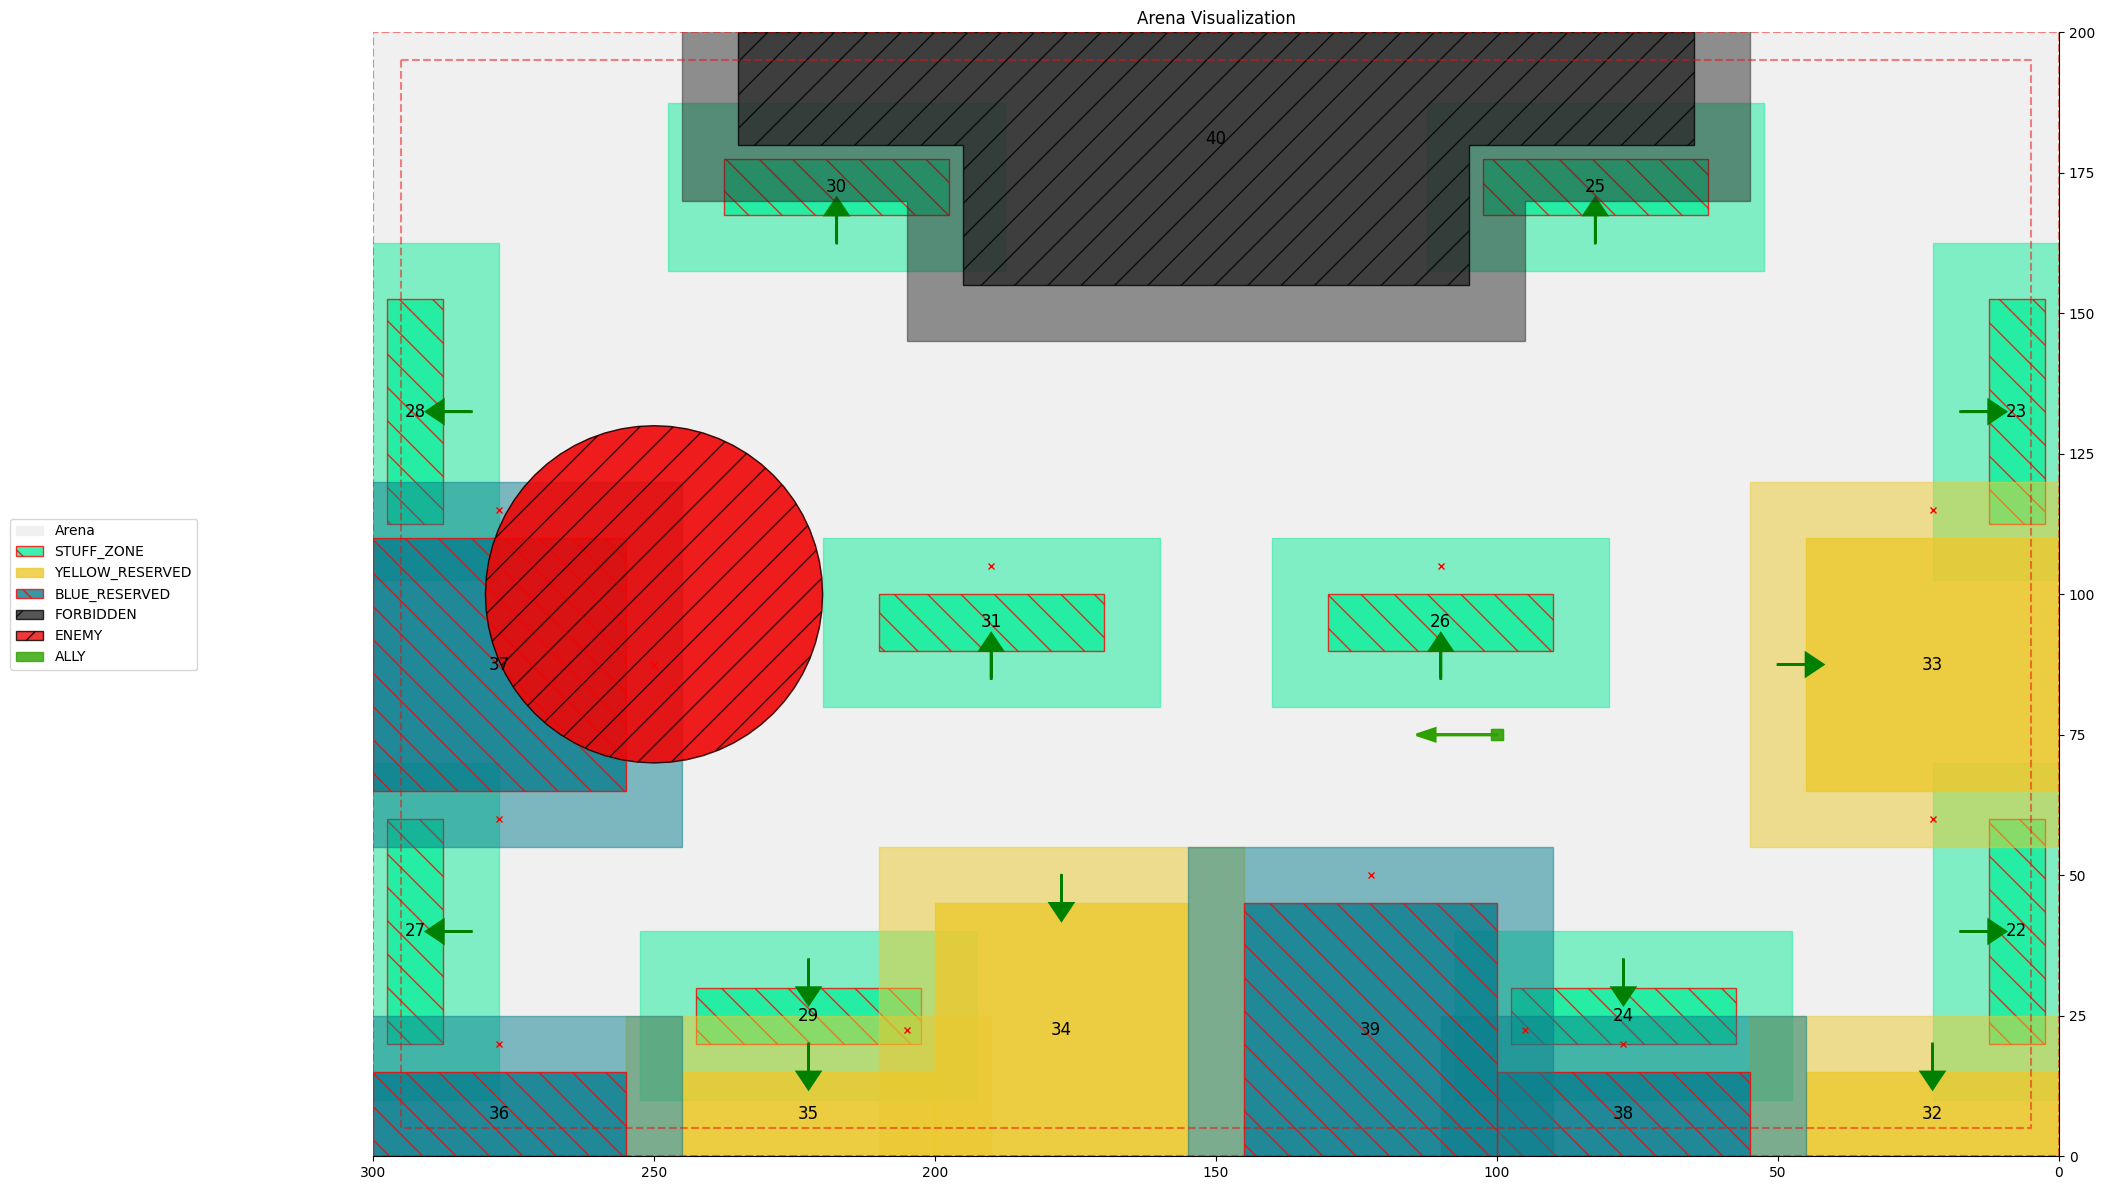

In [ ]:
from IPython.display import clear_output, display

while navigator.current_task is not None:
    cmd: TrajectoryPlanCommand = navigator.handle(
        ally_zone=arena.ally_zone,
        enemy_zone=arena.enemy_zone,
    )

    arena.update(
        ally_position=cmd.position,
        lidar_scan_polars=np.array([]),
        optimized_update=False,
        _enemy_position=Point(250, 100),
    )

    clear_output(wait=True)       
    print("Current task:", getattr(navigator.current_task, "state", None))
    arena.visualize(show_buffer=True)  

    time.sleep(1) 